# Loading data + preprocessing

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import datasets, layers, models

(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 19s 0us/step


In [2]:
X_train.shape, y_train.shape

((50000, 32, 32, 3), (50000, 1))

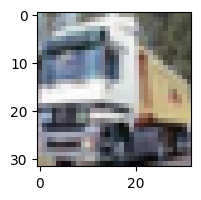

In [3]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,2))
plt.imshow(X_train[1])

In [4]:
# Normalize training data
X_train = X_train/255.0
X_test = X_test/255.0

# Building the CNN model

In [5]:
with tf.device('GPU:0'):
  cnn = models.Sequential([
    # Convolution layers
    layers.Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Dense layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
    ])

  cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

  cnn.fit(X_train, y_train, epochs=10)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.3917 - loss: 1.6842
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6206 - loss: 1.0771
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6706 - loss: 0.9388
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7046 - loss: 0.8468
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7370 - loss: 0.7625
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7509 - loss: 0.7114
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7650 - loss: 0.6647
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7796 - loss: 0.6260
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8020 - loss: 0.5684
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8097 - loss: 0.5423


In [6]:
cnn.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6884 - loss: 0.9820


[0.989432692527771, 0.6901999711990356]

In [8]:
y_pred = cnn.predict(X_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[5.77494176e-03, 6.55389013e-05, 1.67434482e-04, 9.64752495e-01,
        8.84626279e-05, 2.80106887e-02, 2.63654943e-06, 1.09919894e-03,
        1.30386225e-05, 2.56866842e-05],
       [2.26592086e-02, 6.15303516e-01, 1.52084494e-05, 4.96266466e-06,
        2.15447071e-05, 2.04974512e-07, 8.87572256e-08, 5.99116447e-06,
        3.53798181e-01, 8.19107983e-03],
       [2.18768463e-01, 9.12136883e-02, 6.51239464e-03, 3.64640504e-01,
        4.07014834e-03, 3.83178564e-03, 1.69604609e-03, 7.30513036e-03,
        2.86299527e-01, 1.56622678e-02],
       [7.82723188e-01, 3.52877006e-03, 1.27090616e-02, 4.02822997e-03,
        9.37500410e-03, 1.22772299e-05, 3.14965037e-05, 1.28621396e-04,
        1.87269449e-01, 1.93805288e-04],
       [1.44194200e-06, 9.61450041e-06, 1.14208402e-03, 1.06270194e-01,
        1.18923804e-03, 2.36494490e-03, 8.89016747e-01, 3.29637851e-06,
        1.01051592e-06, 1.41933765e-06]], dtype=float32)

In [9]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]

[np.int64(3), np.int64(1), np.int64(3), np.int64(0), np.int64(6)]

In [10]:
y_test[:5]

array([[3],
       [8],
       [8],
       [0],
       [6]], dtype=uint8)

<Axes: >

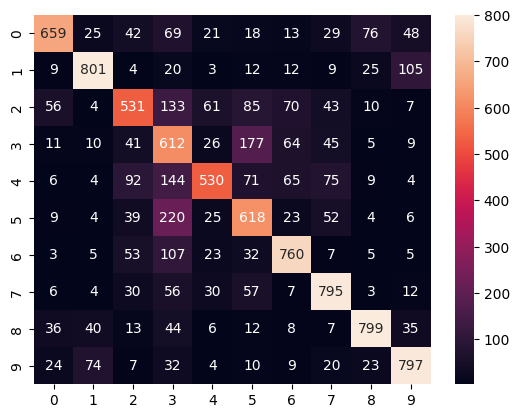

In [13]:
import seaborn as sns
cm = tf.math.confusion_matrix(labels=y_test, predictions=y_classes)
sns.heatmap(cm, annot=True, fmt='d')

In [11]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_classes))

              precision    recall  f1-score   support

           0       0.80      0.66      0.72      1000
           1       0.82      0.80      0.81      1000
           2       0.62      0.53      0.57      1000
           3       0.43      0.61      0.50      1000
           4       0.73      0.53      0.61      1000
           5       0.57      0.62      0.59      1000
           6       0.74      0.76      0.75      1000
           7       0.73      0.80      0.76      1000
           8       0.83      0.80      0.82      1000
           9       0.78      0.80      0.79      1000

    accuracy                           0.69     10000
   macro avg       0.71      0.69      0.69     10000
weighted avg       0.71      0.69      0.69     10000

